In [1]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, load_diabetes, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
from tqdm import tqdm
import copy
plt.style.use("default")

In [2]:
import torch

In [3]:
X, y = load_diabetes(return_X_y=True)

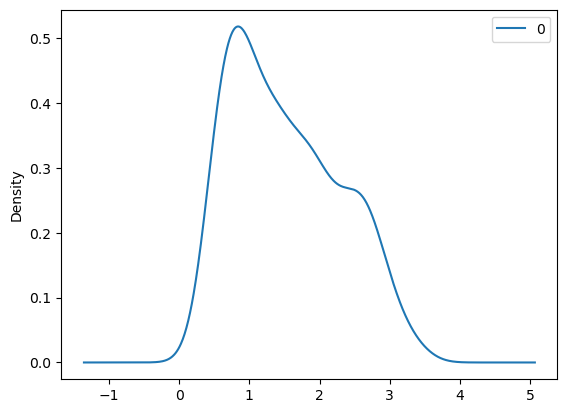

In [5]:
pd.DataFrame(y/100).plot.kde()
plt.show()

In [6]:
class GammaRegression(torch.nn.Module):

    def __init__(
        self,
        input_dim,
        lr=1e-3,
        batch_size=32,
        device=None,
        bias=True,
        bootstrap_bayes=False,
        dirichlet_alpha=1.0
    ):

        super().__init__()

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.batch_size = batch_size
        self.lr = lr

        self.bootstrap_bayes = bootstrap_bayes
        self.dirichlet_alpha = dirichlet_alpha

        self.linear = torch.nn.Linear(input_dim, 1, bias=bias)

        self.log_alpha = torch.nn.Parameter(torch.tensor(0.0))

        self.loss_history = []
        self.val_loss_history = []

        self.to(self.device)

    def forward(self, x):

        x = x.to(self.device)

        mu = torch.exp(self.linear(x))

        alpha = torch.exp(self.log_alpha)

        rate = alpha / mu

        return alpha, rate, mu

    def predict(self, x):

        x = x.to(self.device)

        return torch.exp(self.linear(x))

    def loss(self, x, y, weights=None):

        alpha, rate, _ = self.forward(x)

        gamma_dist = torch.distributions.Gamma(alpha, rate)

        log_prob = gamma_dist.log_prob(y)

        # negative log likelihood individual
        nll = -log_prob

        # Bootstrap Bayesiano
        if weights is not None:

            weights = weights.to(self.device)

            loss = (weights * nll).sum()

        else:

            loss = nll.mean()

        return loss

    def sample_dirichlet_weights(self, n):

        alpha = torch.ones(n, device=self.device) * self.dirichlet_alpha

        weights = torch.distributions.Dirichlet(alpha).sample()

        return weights

    def fit(
        self,
        X,
        y,
        X_val=None,
        y_val=None,
        epochs=50,
        patience=5,
        tol=1e-4,
        verbose=True
    ):

        X = X.to(self.device)

        y = y.to(self.device)

        if X_val is not None and y_val is not None:

            X_val = X_val.to(self.device)

            y_val = y_val.to(self.device)

        optimizer = torch.optim.SGD(
            self.parameters(),
            lr=self.lr
        )

        best_loss = float("inf")

        best_state = None

        patience_counter = 0

        if verbose:

            pbar = tqdm(
                range(epochs),
                desc="Training",
                leave=True
            )

        else:

            pbar = range(epochs)

        n = len(X)

        for epoch in pbar:

            self.train()

            optimizer.zero_grad()

            # Bootstrap Bayesiano
            if self.bootstrap_bayes:

                weights = self.sample_dirichlet_weights(n)

            else:

                weights = None

            loss = self.loss(X, y, weights)

            loss.backward()

            optimizer.step()

            epoch_loss = loss.item()

            self.loss_history.append(epoch_loss)

            if X_val is not None and y_val is not None:

                self.eval()

                with torch.no_grad():

                    val_loss = self.loss(X_val, y_val).item()

                self.val_loss_history.append(val_loss)

                if val_loss < best_loss - tol:

                    best_loss = val_loss

                    best_state = copy.deepcopy(self.state_dict())

                    patience_counter = 0

                else:

                    patience_counter += 1
                if verbose:

                    pbar.set_postfix({
                    "train_loss": f"{epoch_loss:.4f}",
                    "val_loss": f"{val_loss:.4f}",
                    "alpha": f"{torch.exp(self.log_alpha).item():.4f}"
                })

                if patience_counter >= patience:
                    break

            else:

                if verbose:

                    pbar.set_postfix({
                    "train_loss": f"{epoch_loss:.4f}",
                    "alpha": f"{torch.exp(self.log_alpha).item():.4f}"
                })

        if best_state is not None:

            self.load_state_dict(best_state)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
pca = PCA().fit(X_train)

pca.explained_variance_ratio_.cumsum()

array([0.39444022, 0.54629658, 0.67222044, 0.76775954, 0.83397053,
       0.89464284, 0.94948488, 0.99173889, 0.99927259, 1.        ])

In [8]:
X_train = pca.transform(X_train)[:, :8]
X_test = pca.transform(X_test)[:, :8]

In [9]:
X_train, X_test = torch.Tensor(X_train), torch.Tensor(X_test)
y_train, y_test = torch.Tensor(y_train), torch.Tensor(y_test)

In [10]:
p = X_train.shape[1]
gamma_model = GammaRegression(
    p, lr=1e-2)

In [11]:
gamma_model.fit(X_train, y_train/100, X_test, y_test/100, epochs=500, tol=1e-6)

Training: 100%|██████████| 500/500 [00:04<00:00, 102.94it/s, train_loss=1.0764, val_loss=1.1958, alpha=3.1345]


In [12]:
gamma_model.log_alpha.exp()

tensor(3.1345, device='cuda:0', grad_fn=<ExpBackward0>)

In [18]:
class LinearRegression(torch.nn.Module):

    def __init__(
        self,
        input_dim,
        lr=1e-3,
        batch_size=32,
        device=None,
        bias=True,
        bootstrap_bayes=False,
        dirichlet_alpha=1.0
    ):

        super().__init__()

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.batch_size = batch_size
        self.lr = lr

        self.bootstrap_bayes = bootstrap_bayes
        self.dirichlet_alpha = dirichlet_alpha

        self.linear = torch.nn.Linear(input_dim, 1, bias=bias)

        # log(sigma)
        self.log_sigma = torch.nn.Parameter(torch.tensor(0.0))

        self.loss_history = []
        self.val_loss_history = []

        self.to(self.device)

    def forward(self, x):

        x = x.to(self.device)

        mu = self.linear(x)

        sigma = torch.exp(self.log_sigma)

        return mu, sigma

    def predict(self, x):

        x = x.to(self.device)

        return self.linear(x)

    def sample_dirichlet_weights(self, n):

        alpha = torch.ones(
            n,
            device=self.device
        ) * self.dirichlet_alpha

        weights = torch.distributions.Dirichlet(alpha).sample()

        return weights

    def loss(self, x, y, weights=None):

        y = y.to(self.device)

        mu, sigma = self.forward(x)

        normal_dist = torch.distributions.Normal(mu, sigma)

        # NLL individual
        nll = -normal_dist.log_prob(y).squeeze()

        # Bootstrap Bayesiano
        if weights is not None:

            weights = weights.to(self.device)

            loss = (weights * nll).sum()

        else:

            loss = nll.mean()

        return loss

    def fit(
        self,
        X,
        y,
        X_val=None,
        y_val=None,
        epochs=50,
        patience=5,
        tol=1e-4,
        verbose=True
    ):

        X = X.to(self.device)

        y = y.to(self.device)

        if X_val is not None and y_val is not None:

            X_val = X_val.to(self.device)

            y_val = y_val.to(self.device)

        optimizer = torch.optim.SGD(
            self.parameters(),
            lr=self.lr
        )

        best_loss = float("inf")

        best_state = None

        patience_counter = 0

        if verbose:

            pbar = tqdm(
                range(epochs),
                desc="Training",
                leave=True
            )

        else:

            pbar = range(epochs)

        n = len(X)

        for epoch in pbar:

            self.train()

            optimizer.zero_grad()

            # Bootstrap Bayesiano
            if self.bootstrap_bayes:

                weights = self.sample_dirichlet_weights(n)

            else:

                weights = None

            loss = self.loss(X, y, weights)

            loss.backward()

            optimizer.step()

            epoch_loss = loss.item()

            self.loss_history.append(epoch_loss)

            if X_val is not None and y_val is not None:

                self.eval()

                with torch.no_grad():

                    val_loss = self.loss(X_val, y_val).item()

                self.val_loss_history.append(val_loss)

                if val_loss < best_loss - tol:

                    best_loss = val_loss

                    best_state = copy.deepcopy(self.state_dict())

                    patience_counter = 0

                else:

                    patience_counter += 1
                if verbose:

                    pbar.set_postfix({
                    "train_loss": f"{epoch_loss:.4f}",
                    "val_loss": f"{val_loss:.4f}",
                    "sigma": f"{torch.exp(self.log_sigma).item():.4f}"
                })

                if patience_counter >= patience:
                    break

            else:

                if verbose:

                    pbar.set_postfix({
                    "train_loss": f"{epoch_loss:.4f}",
                    "sigma": f"{torch.exp(self.log_sigma).item():.4f}"
                })

        if best_state is not None:

            self.load_state_dict(best_state)

In [19]:
linear_regression = LinearRegression(p, lr=1e-2)
linear_regression.fit(X_train, y_train/100, X_test, y_test/100, epochs=100, tol=1e-5)

Training: 100%|██████████| 100/100 [00:00<00:00, 140.86it/s, train_loss=1.4511, val_loss=1.5721, sigma=1.1539]


In [22]:
class LaplaceRegression(torch.nn.Module):

    def __init__(
        self,
        input_dim,
        lr=1e-3,
        batch_size=32,
        device=None,
        bias=True,
        bootstrap_bayes=False,
        dirichlet_alpha=1.0
    ):

        super().__init__()

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.batch_size = batch_size
        self.lr = lr

        self.bootstrap_bayes = bootstrap_bayes
        self.dirichlet_alpha = dirichlet_alpha

        self.linear = torch.nn.Linear(
            input_dim,
            1,
            bias=bias
        )

        self.log_scale = torch.nn.Parameter(
            torch.tensor(0.0)
        )

        self.loss_history = []

        self.val_loss_history = []

        self.to(self.device)

    def forward(self, x):

        x = x.to(self.device)

        mu = self.linear(x)

        scale = torch.exp(self.log_scale)

        return mu, scale

    def predict(self, x):

        x = x.to(self.device)

        return self.linear(x)

    def sample_dirichlet_weights(self, n):

        alpha = torch.ones(
            n,
            device=self.device
        ) * self.dirichlet_alpha

        weights = torch.distributions.Dirichlet(
            alpha
        ).sample()

        return weights

    def loss(self, x, y, weights=None):

        y = y.to(self.device)

        mu, scale = self.forward(x)

        laplace_dist = torch.distributions.Laplace(
            mu,
            scale
        )

        # NLL individual
        nll = -laplace_dist.log_prob(y).squeeze()

        # Bootstrap Bayesiano
        if weights is not None:

            weights = weights.to(self.device)

            loss = (weights * nll).sum()

        else:

            loss = nll.mean()

        return loss

    def fit(
            self,
            X,
            y,
            X_val=None,
            y_val=None,
            epochs=50,
            patience=5,
            tol=1e-4,
            verbose=True
        ):

            X = X.to(self.device)

            y = y.to(self.device)

            if X_val is not None and y_val is not None:

                X_val = X_val.to(self.device)

                y_val = y_val.to(self.device)

            optimizer = torch.optim.SGD(
                self.parameters(),
                lr=self.lr
            )

            best_loss = float("inf")

            best_state = None

            patience_counter = 0

            if verbose:

                pbar = tqdm(
                    range(epochs),
                    desc="Training",
                    leave=True
                )

            else:

                pbar = range(epochs)

            n = len(X)

            for epoch in pbar:

                self.train()

                optimizer.zero_grad()

                # Bootstrap Bayesiano
                if self.bootstrap_bayes:

                    weights = self.sample_dirichlet_weights(n)

                else:

                    weights = None

                loss = self.loss(X, y, weights)

                loss.backward()

                optimizer.step()

                epoch_loss = loss.item()

                self.loss_history.append(epoch_loss)

                if X_val is not None and y_val is not None:

                    self.eval()

                    with torch.no_grad():

                        val_loss = self.loss(X_val, y_val).item()

                    self.val_loss_history.append(val_loss)

                    if val_loss < best_loss - tol:

                        best_loss = val_loss

                        best_state = copy.deepcopy(self.state_dict())

                        patience_counter = 0

                    else:

                        patience_counter += 1
                    if verbose:

                        pbar.set_postfix({
                        "train_loss": f"{epoch_loss:.4f}",
                        "val_loss": f"{val_loss:.4f}",
                        "scale": f"{torch.exp(self.log_scale).item():.4f}"
                    })

                    if patience_counter >= patience:
                        break

                else:

                    if verbose:

                        pbar.set_postfix({
                        "train_loss": f"{epoch_loss:.4f}",
                        "scale": f"{torch.exp(self.log_scale).item():.4f}"
                    })

            if best_state is not None:

                self.load_state_dict(best_state)

In [23]:
laplace_regression = LaplaceRegression(p, lr=1e-2)
laplace_regression.fit(X_train, y_train/100, X_test, y_test/100, epochs=1000)

Training:  42%|████▏     | 415/1000 [00:02<00:03, 190.35it/s, train_loss=1.2367, val_loss=1.3804, scale=0.6569]


In [32]:
class LogisticRegression(torch.nn.Module):

    def __init__(
        self,
        input_dim,
        lr=1e-3,
        batch_size=32,
        device=None,
        bias=True,
        bootstrap_bayes=False,
        dirichlet_alpha=1.0
    ):

        super().__init__()

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.batch_size = batch_size
        self.lr = lr

        self.bootstrap_bayes = bootstrap_bayes

        self.dirichlet_alpha = dirichlet_alpha

        self.linear = torch.nn.Linear(
            input_dim,
            1,
            bias=bias
        )

        self.loss_history = []

        self.val_loss_history = []

        self.to(self.device)

    def forward(self, x):

        x = x.to(self.device)

        logits = self.linear(x).squeeze(-1)

        return logits

    def predict_proba(self, x):

        x = x.to(self.device)

        logits = self.forward(x)

        return torch.sigmoid(logits)

    def predict(self, x, threshold=0.5):

        probs = self.predict_proba(x)

        return (probs >= threshold).float()

    def sample_dirichlet_weights(self, n):

        alpha = torch.ones(
            n,
            device=self.device
        ) * self.dirichlet_alpha

        weights = torch.distributions.Dirichlet(
            alpha
        ).sample()

        return weights

    def loss(self, x, y, weights=None):

        y = y.to(self.device).float()

        logits = self.forward(x)

        # BCE individual
        criterion = torch.nn.BCEWithLogitsLoss(
            reduction="none"
        )

        nll = criterion(logits, y)

        # Bootstrap Bayesiano
        if weights is not None:

            weights = weights.to(self.device)

            loss = (weights * nll).sum()

        else:

            loss = nll.mean()

        return loss

    def fit(
        self,
        X,
        y,
        X_val=None,
        y_val=None,
        epochs=50,
        patience=5,
        tol=1e-4,
        verbose=True
    ):

        X = X.to(self.device)

        y = y.to(self.device)

        if X_val is not None and y_val is not None:

            X_val = X_val.to(self.device)

            y_val = y_val.to(self.device)

        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.lr
        )

        best_loss = float("inf")

        best_state = None

        patience_counter = 0

        if verbose:

            pbar = tqdm(
                range(epochs),
                desc="Training",
                leave=True
            )

        else:

            pbar = range(epochs)

        n = len(X)

        for epoch in pbar:

            self.train()

            optimizer.zero_grad()

            # Bootstrap Bayesiano
            if self.bootstrap_bayes:

                weights = self.sample_dirichlet_weights(n)

            else:

                weights = None

            loss = self.loss(X, y, weights)

            loss.backward()

            optimizer.step()

            epoch_loss = loss.item()

            self.loss_history.append(epoch_loss)

            if X_val is not None and y_val is not None:

                self.eval()

                with torch.no_grad():

                    val_loss = self.loss(
                        X_val,
                        y_val
                    ).item()

                self.val_loss_history.append(val_loss)

                if val_loss < best_loss - tol:

                    best_loss = val_loss

                    best_state = copy.deepcopy(
                        self.state_dict()
                    )

                    patience_counter = 0

                else:

                    patience_counter += 1

                preds = self.predict(X_val)

                acc = (
                    (preds == y_val)
                    .float()
                    .mean()
                    .item()
                )

                if verbose:

                    pbar.set_postfix({
                        "train_loss": f"{epoch_loss:.4f}",
                        "val_loss": f"{val_loss:.4f}",
                        "val_acc": f"{acc:.4f}"
                    })

                if patience_counter >= patience:
                    break

            else:

                if verbose:

                    pbar.set_postfix({
                        "train_loss": f"{epoch_loss:.4f}"
                    })

        if best_state is not None:

            self.load_state_dict(best_state)

In [33]:
data = load_iris()

X = data.data
y = (data.target == 0).astype(int)

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
pca = PCA().fit(X_train)
pca.explained_variance_ratio_.cumsum()

array([0.72623251, 0.96075202, 0.99448541, 1.        ])

In [99]:
X_train = pca.transform(X_train)[:, :2]
X_test = pca.transform(X_test)[:, :2]

In [100]:
X_train, X_test = torch.Tensor(X_train), torch.Tensor(X_test)
y_train, y_test = torch.Tensor(y_train), torch.Tensor(y_test)

In [107]:
log_reg = LogisticRegression(2, lr=1e-3)

In [108]:
log_reg.fit(X_train, y_train, X_test, y_test, epochs=600, tol=1e-3, patience=2)

Training:  38%|███▊      | 228/600 [00:01<00:01, 219.44it/s, train_loss=0.3381, val_loss=0.3488, val_acc=0.9667]


In [109]:
def bootstrap_ensemble(
    model_class,
    X_train,
    y_train,
    B=100,
    sample_size=None,
    seed=123,
    model_kwargs=None,
    fit_kwargs=None
):

    """
    Entrena un ensamble usando Bootstrap clásico.

    Parámetros
    ----------
    model_class : clase
        Clase del modelo.

    X_train : torch.Tensor
    y_train : torch.Tensor

    B : int
        Número de modelos Bootstrap.

    sample_size : int
        Tamaño de cada remuestra Bootstrap.
        Si es None usa n.

    seed : int
        Semilla aleatoria.

    model_kwargs : dict
        Parámetros del constructor del modelo.

    fit_kwargs : dict
        Parámetros para model.fit()

    Returns
    -------
    models : list
        Lista de modelos entrenados.
    """

    if model_kwargs is None:
        model_kwargs = {}

    if fit_kwargs is None:
        fit_kwargs = {}

    torch.manual_seed(seed)

    np.random.seed(seed)

    n = len(X_train)

    # Bootstrap clásico estándar
    if sample_size is None:

        sample_size = n

    models = []

    pbar = tqdm(
        range(B),
        desc="Bootstrap Ensemble",
        leave=True
    )

    for b in pbar:

        # índices con reemplazo
        idx = torch.randint(
            low=0,
            high=n,
            size=(sample_size,)
        )

        X_boot = X_train[idx]

        y_boot = y_train[idx]

        # crear modelo
        model = model_class(
            input_dim=X_train.shape[1],
            **model_kwargs
        )

        # entrenar
        model.fit(
            X_boot,
            y_boot,
            verbose=False,
            **fit_kwargs
        )

        models.append(
            copy.deepcopy(model)
        )

    return models

In [112]:
log_reg_models = bootstrap_ensemble(LogisticRegression, X_train, y_train, B=500, seed=123,
                                    model_kwargs={"lr":1e-3}, fit_kwargs={"epochs":600})

Bootstrap Ensemble: 100%|██████████| 500/500 [05:37<00:00,  1.48it/s]


In [113]:
def predict_voting(models, X, threshold=0.5):

    preds = []

    for model in models:

        pred = model.predict(
            X,
            threshold=threshold
        )

        preds.append(pred)

    preds = torch.stack(preds)

    # mayoría
    final_pred = (
        preds.float()
        .mean(dim=0) >= 0.5
    ).float()

    return final_pred

In [245]:
y_pred = predict_voting(log_reg_models, X_test)

In [246]:
(y_pred.cpu() == y_test).float().mean()

tensor(1.)

In [143]:
def extract_betas(models):

    betas = []

    biases = []

    for model in models:

        beta = (
            model.linear.weight
            .detach()
            .cpu()
            .flatten()
        )

        bias = (
            model.linear.bias
            .detach()
            .cpu()
        )

        betas.append(beta)

        biases.append(bias)

    betas = torch.stack(betas)

    biases = torch.stack(biases)

    return betas, biases

In [144]:
betas, biases = extract_betas(log_reg_models)

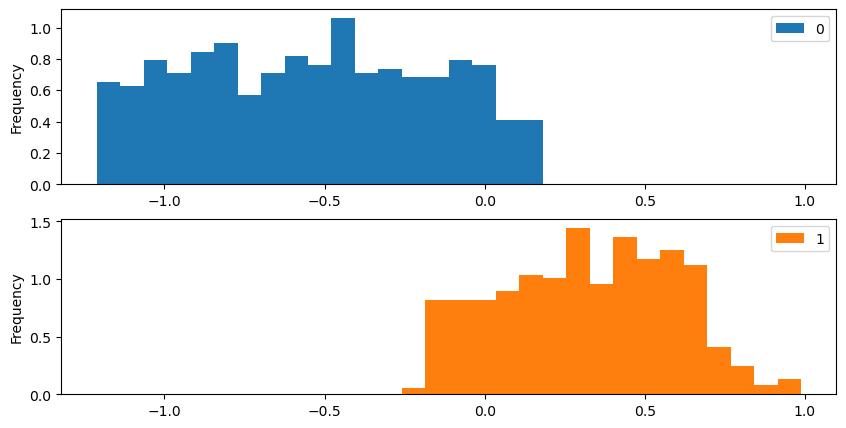

In [149]:
pd.DataFrame(betas).plot.hist(subplots=True, figsize=(10, 5), sharex=False, density=True, bins=30)
plt.show()

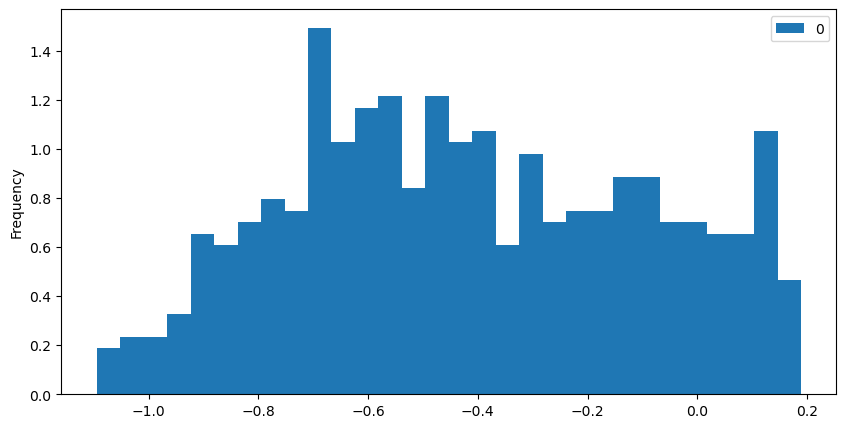

In [152]:
pd.DataFrame(biases).plot.hist(figsize=(10, 5), density=True, bins=30)
plt.show()

In [154]:
biases.quantile(torch.Tensor([0.025, 0.975]))

tensor([-0.9725,  0.1423])

In [157]:
betas.quantile(torch.Tensor([0.025, 0.975]), dim=0)

tensor([[-1.1627, -0.1532],
        [ 0.1174,  0.7940]])

In [150]:
def bayesian_bootstrap_ensemble(
    model_class,
    X_train,
    y_train,
    B=100,
    seed=123,
    model_kwargs=None,
    fit_kwargs=None,
    dirichlet_alpha=1.0
):

    """
    Entrena un ensamble usando Bootstrap Bayesiano.

    Parámetros
    ----------
    model_class : clase
        Clase del modelo.

    X_train : torch.Tensor
    y_train : torch.Tensor

    B : int
        Número de modelos.

    seed : int
        Semilla aleatoria.

    model_kwargs : dict
        Parámetros del constructor del modelo.

    fit_kwargs : dict
        Parámetros para model.fit()

    dirichlet_alpha : float
        Parámetro de la Dirichlet.

    Returns
    -------
    models : list
        Lista de modelos entrenados.
    """

    if model_kwargs is None:

        model_kwargs = {}

    if fit_kwargs is None:

        fit_kwargs = {}

    torch.manual_seed(seed)

    np.random.seed(seed)

    models = []

    pbar = tqdm(
        range(B),
        desc="Bayesian Bootstrap Ensemble",
        leave=True
    )

    for b in pbar:

        model = model_class(
            input_dim=X_train.shape[1],
            bootstrap_bayes=True,
            dirichlet_alpha=dirichlet_alpha,
            **model_kwargs
        )

        model.fit(
            X_train,
            y_train,
            verbose=False,
            **fit_kwargs
        )

        models.append(
            copy.deepcopy(model)
        )

    return models

In [213]:
log_reg_models2 = bayesian_bootstrap_ensemble(LogisticRegression, X_train, y_train, B=1000, seed=123,
                                    model_kwargs={"lr":1e-2}, fit_kwargs={"epochs":50})

Bayesian Bootstrap Ensemble: 100%|██████████| 1000/1000 [01:40<00:00,  9.92it/s]


In [214]:
betas, biases = extract_betas(log_reg_models2)

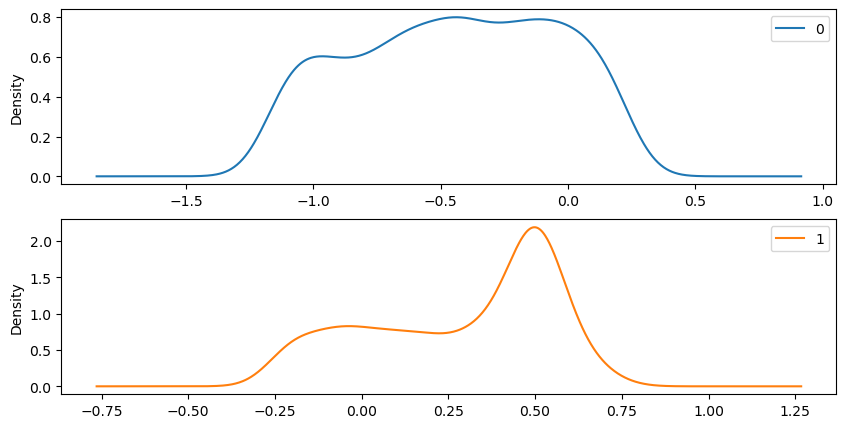

tensor([[-1.1331, -0.2211],
        [ 0.1927,  0.6500]])


In [215]:
pd.DataFrame(betas).plot.kde(subplots=True, figsize=(10, 5), sharex=False)
plt.show()
print(betas.quantile(torch.Tensor([0.025, 0.975]), dim=0))

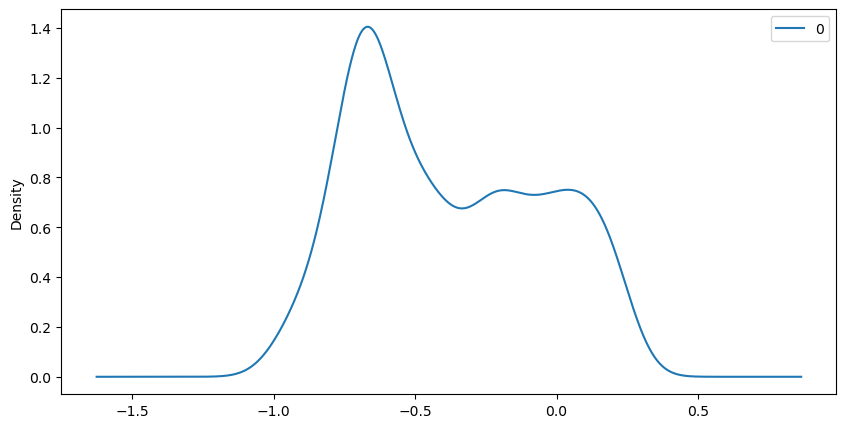

tensor([-0.9016,  0.2073])


In [216]:
pd.DataFrame(biases).plot.kde(subplots=True, figsize=(10, 5), sharex=False)
plt.show()
print(biases.quantile(torch.Tensor([0.025, 0.975])))

In [217]:
def ensemble_accuracies(
    models,
    X,
    y,
    threshold=0.5
):

    accuracies = []

    y = y.cpu()

    for model in models:

        model.eval()

        with torch.no_grad():

            preds = model.predict(
                X,
                threshold=threshold
            ).cpu()

            acc = (
                (preds == y)
                .float()
                .mean()
                .item()
            )

        accuracies.append(acc)

    return torch.tensor(accuracies)

In [218]:
accs = ensemble_accuracies(
    log_reg_models2,
    X_test,
    y_test,
    threshold=0.5
)

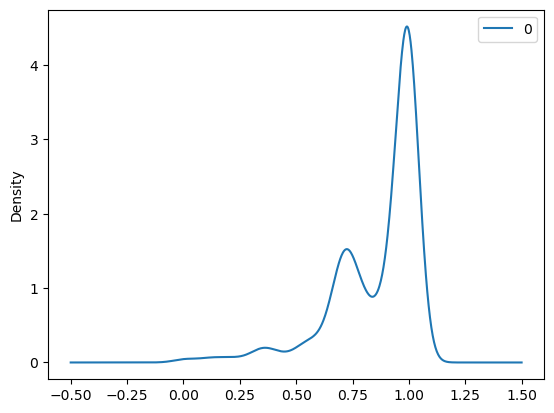

In [219]:
pd.DataFrame(accs).plot.kde()
plt.show()

In [220]:
accs.quantile(torch.Tensor([0.025, 0.975]))

tensor([0.3333, 1.0000])

In [238]:
y_pred = predict_voting(log_reg_models2, X_test)

In [239]:
(y_pred.cpu() == y_test).float().mean()

tensor(1.)